## Sumbit example

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

print(train_data.head())

train_data.fillna(train_data.median(numeric_only=True), inplace=True)
categorical_cols = train_data.select_dtypes(include='object').columns
for col in categorical_cols:
    le = LabelEncoder()
    train_data[col] = le.fit_transform(train_data[col])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(train_data.drop(columns=['LoanApproved']))
X = pd.DataFrame(scaled_features, columns=train_data.drop(columns=['LoanApproved']).columns)
y = train_data['LoanApproved']


  ApplicationDate   Age  AnnualIncome  CreditScore  LoanAmount  LoanDuration  \
0      2010-06-26  27.0       66829.0        549.0     17290.0          60.0   
1      1996-09-23  55.0      172147.0        850.0     16110.0          36.0   
2      2015-01-19  51.0      300000.0        850.0     38436.0          36.0   
3      1981-05-12  25.0       34683.0        847.0     19186.0          48.0   
4      1995-05-07  55.0      300000.0        850.0     30437.0          48.0   

  MaritalStatus  NumberOfDependents HomeOwnershipStatus  MonthlyDebtPayments  \
0      Divorced                 1.0                Rent               1095.0   
1       Widowed                 1.0            Mortgage                211.0   
2       Married                 0.0            Mortgage                546.0   
3       Married                 0.0               Other                153.0   
4        Single                 2.0                Rent                562.0   

   ...  EmploymentStatus  EducationLev

In [19]:
class LinearClassifier:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            linear_output = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_output)
            
            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted - y)
            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_output)
        y_predicted_class = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_class)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [5]:
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [6]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [7]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [8]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

In [9]:
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

[LightGBM] [Info] Number of positive: 4710, number of negative: 4103
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001019 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5097
[LightGBM] [Info] Number of data points in the train set: 8813, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.534438 -> initscore=0.137969
[LightGBM] [Info] Start training from score 0.137969


In [20]:
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [21]:
cat_model = CatBoostClassifier(silent=True)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)

In [22]:
def evaluate_model(y_test, y_pred):
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
    print(f'Precision: {precision_score(y_test, y_pred):.2f}')
    print(f'Recall: {recall_score(y_test, y_pred):.2f}')
    print(f'F1 Score: {f1_score(y_test, y_pred):.2f}')
    print(classification_report(y_test, y_pred))


In [23]:
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))  
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    plt.close()  


Метрики для Logistic Regression:

Logistic Regression Results:
Accuracy: 0.93
Precision: 0.94
Recall: 0.93
F1 Score: 0.93
              precision    recall  f1-score   support

         0.0       0.92      0.93      0.92      1017
         1.0       0.94      0.93      0.93      1187

    accuracy                           0.93      2204
   macro avg       0.93      0.93      0.93      2204
weighted avg       0.93      0.93      0.93      2204



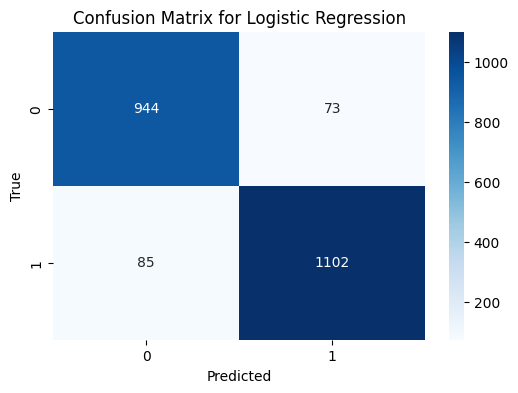

Метрики для SVM:

SVM Results:
Accuracy: 0.92
Precision: 0.95
Recall: 0.91
F1 Score: 0.93
              precision    recall  f1-score   support

         0.0       0.90      0.94      0.92      1017
         1.0       0.95      0.91      0.93      1187

    accuracy                           0.92      2204
   macro avg       0.92      0.92      0.92      2204
weighted avg       0.92      0.92      0.92      2204



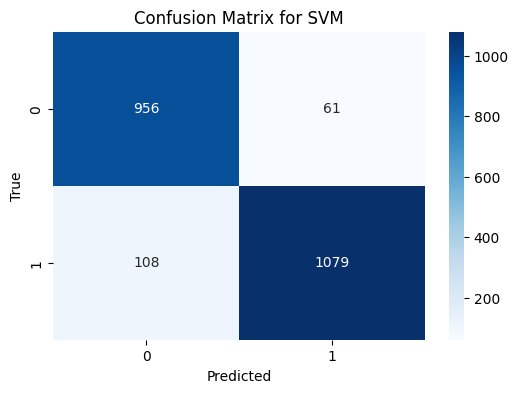

Метрики для Decision Tree:

Decision Tree Results:
Accuracy: 0.98
Precision: 0.98
Recall: 0.98
F1 Score: 0.98
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1017
         1.0       0.98      0.98      0.98      1187

    accuracy                           0.98      2204
   macro avg       0.98      0.98      0.98      2204
weighted avg       0.98      0.98      0.98      2204



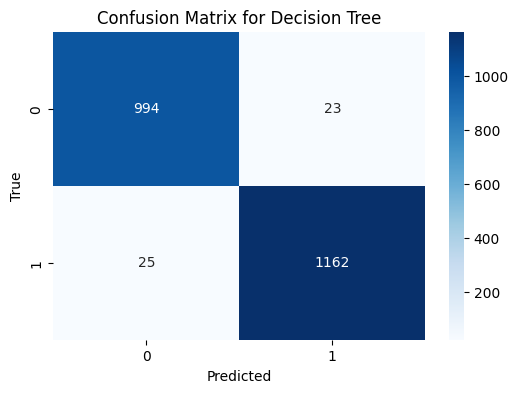

Метрики для Random Forest:

Random Forest Results:
Accuracy: 0.98
Precision: 0.98
Recall: 0.99
F1 Score: 0.98
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1017
         1.0       0.98      0.99      0.98      1187

    accuracy                           0.98      2204
   macro avg       0.98      0.98      0.98      2204
weighted avg       0.98      0.98      0.98      2204



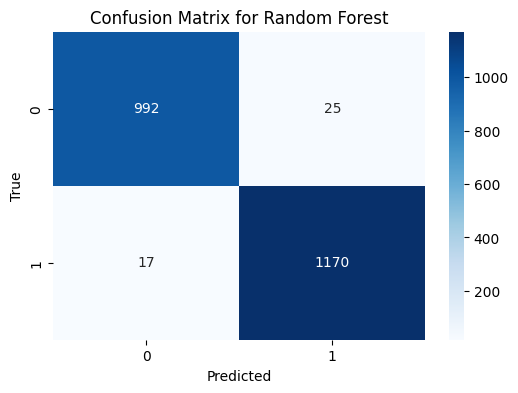

Метрики для Gradient Boosting:

Gradient Boosting Results:
Accuracy: 0.99
Precision: 0.99
Recall: 0.99
F1 Score: 0.99
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1017
         1.0       0.99      0.99      0.99      1187

    accuracy                           0.99      2204
   macro avg       0.98      0.98      0.98      2204
weighted avg       0.99      0.99      0.99      2204



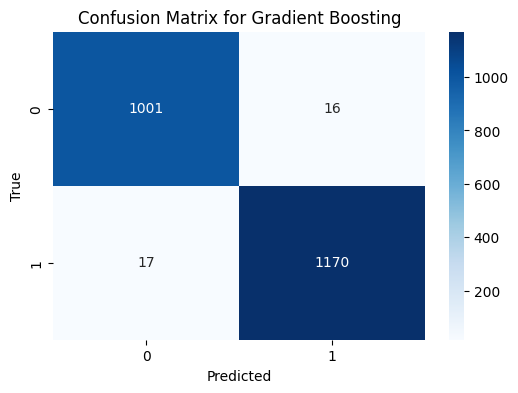

Метрики для LightGBM:

LightGBM Results:
Accuracy: 0.99
Precision: 0.99
Recall: 0.99
F1 Score: 0.99
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1017
         1.0       0.99      0.99      0.99      1187

    accuracy                           0.99      2204
   macro avg       0.99      0.99      0.99      2204
weighted avg       0.99      0.99      0.99      2204



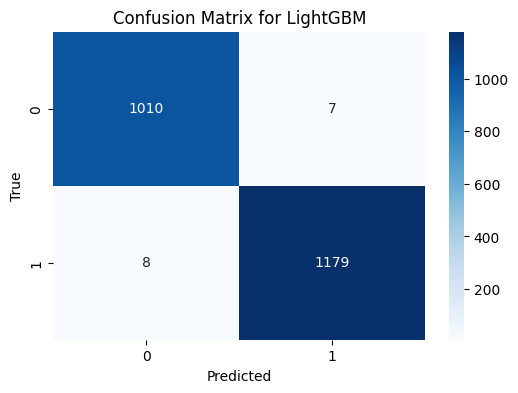

Метрики для XGBoost:

XGBoost Results:
Accuracy: 0.99
Precision: 0.99
Recall: 0.99
F1 Score: 0.99
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1017
         1.0       0.99      0.99      0.99      1187

    accuracy                           0.99      2204
   macro avg       0.99      0.99      0.99      2204
weighted avg       0.99      0.99      0.99      2204



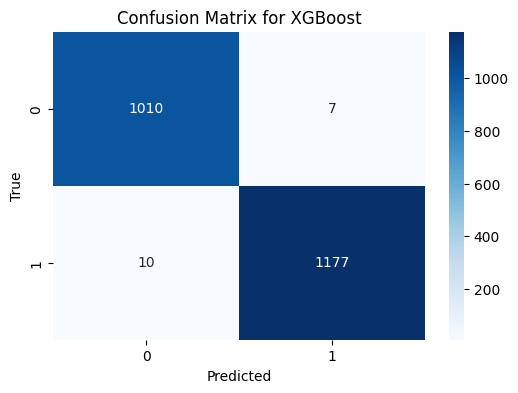

Метрики для CatBoost:

CatBoost Results:
Accuracy: 0.99
Precision: 0.99
Recall: 0.99
F1 Score: 0.99
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1017
         1.0       0.99      0.99      0.99      1187

    accuracy                           0.99      2204
   macro avg       0.99      0.99      0.99      2204
weighted avg       0.99      0.99      0.99      2204



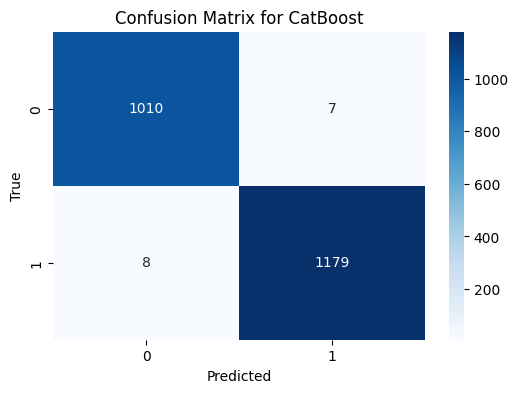

In [24]:
models = {
    'Logistic Regression': y_pred_lr,
    'SVM': y_pred_svm,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb,
    'LightGBM': y_pred_lgb,
    'XGBoost': y_pred_xgb,
    'CatBoost': y_pred_cat
}

for model_name, y_pred in models.items():
    print(f"Метрики для {model_name}:")
    print(f'\n{model_name} Results:')
    evaluate_model(y_test, y_pred)
    plot_confusion_matrix(y_test, y_pred, model_name)


In [ ]:
Выводы

В ходе выполнения лабораторной по задаче бинарной классификации для предсказания одобрения кредита (LoanApproved) я могу сделать следующие выводы:
Логистическая регрессия продемонстрировала приличные результаты, дав возможность интерпретировать важность переменных через коэффициенты модели.
Модели - SVM и решающее дерево - показали свою эффективность, особенно в отношении метрик. Заметим дополнительно, что их производительность может быть чувствительна к выбросам.
Случайный лес, обеспечил устойчивые результаты, сводя к минимуму переобучение.
Градиентный бустинг, LightGBM и XGBoost показали значительное улучшение по сравнению с остальными моделями, что подтверждает их роль в комплексных задачах классификации.
CatBoost оказалась конкурентоспособной, балансируя  скорость обучения и точность.
Метрики precision и recall, в зависимости от контекста задачи, были особенно важны. Высокий уровень precision был очень важен в финансовом контексте, приводив к минимизации ложных одобрений кредитов.
F1-мерная метрика служит компромиссом между precision и recall, и именно она была наиболее информативной в данной задаче, т. к. сигнализировала о том, хорошо ли модель справляется с классификацией положительных классов.

Подытожив можно сказать, я на конкретном примере сумел выявить, что линейный классификатор конечно прост, но менее точен в сравнении с другими реализациями.